ORIGINAL-FEATURE ALPHA MODEL WITH PROFESSIONAL BACKTESTING EXTENSIONS
Engineering original 24-feature set...
Generating sequences...
Universe after cleaning: 496 stocks
Feature count: 24
Train sequences: (773072, 60, 24)
Validation sequences: (218521, 60, 24)
Test sequences: (379737, 60, 24)
Live/latest scored stocks: (496, 60, 24)
Training CNN-LSTM-Attention model...
Epoch 1/30
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - loss: 0.3562 - mae: 0.6929 - val_loss: 0.3705 - val_mae: 0.7141
Epoch 2/30
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.3545 - mae: 0.6907 - val_loss: 0.3749 - val_mae: 0.7199
Epoch 3/30
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.3520 - mae: 0.6876 - val_loss: 0.3787 - val_mae: 0.7246
Epoch 4/30
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.3486 - mae: 0.6832 - val_loss: 0.3868 - val_mae: 0.7345
Epoch 5/30
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.3451 - mae: 0.6788 - val_loss: 0.3920 - val_mae: 0.7412
Epoch 6/30
1510/151

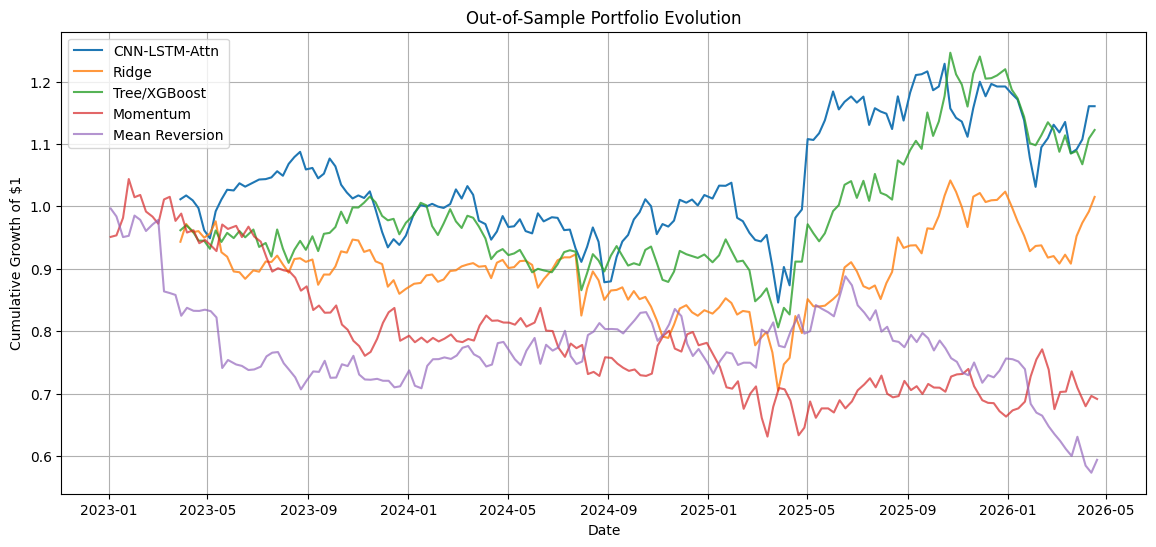

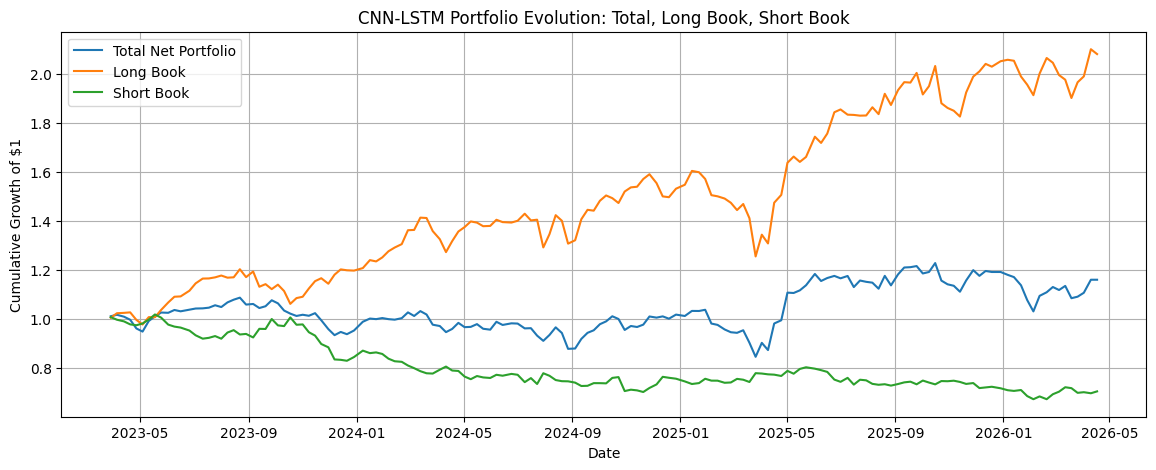

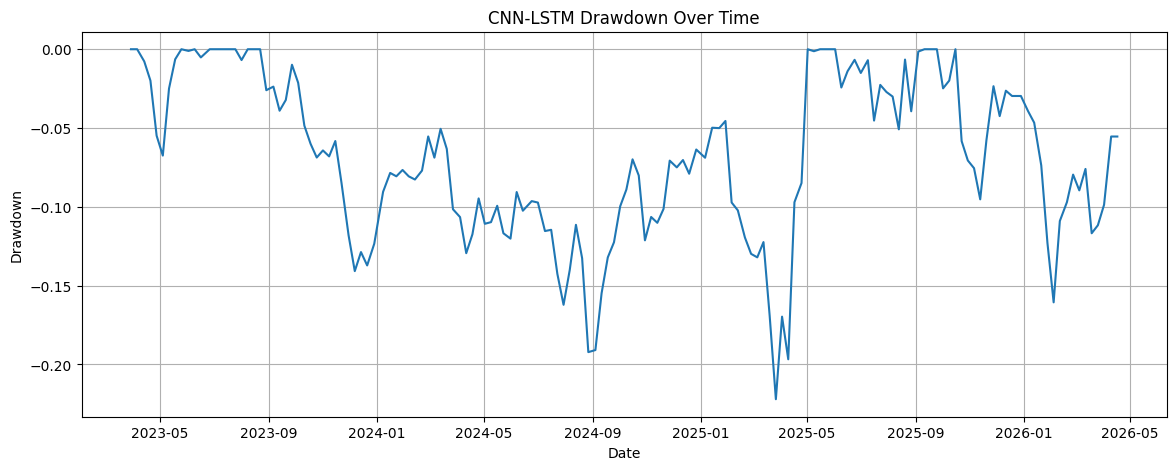

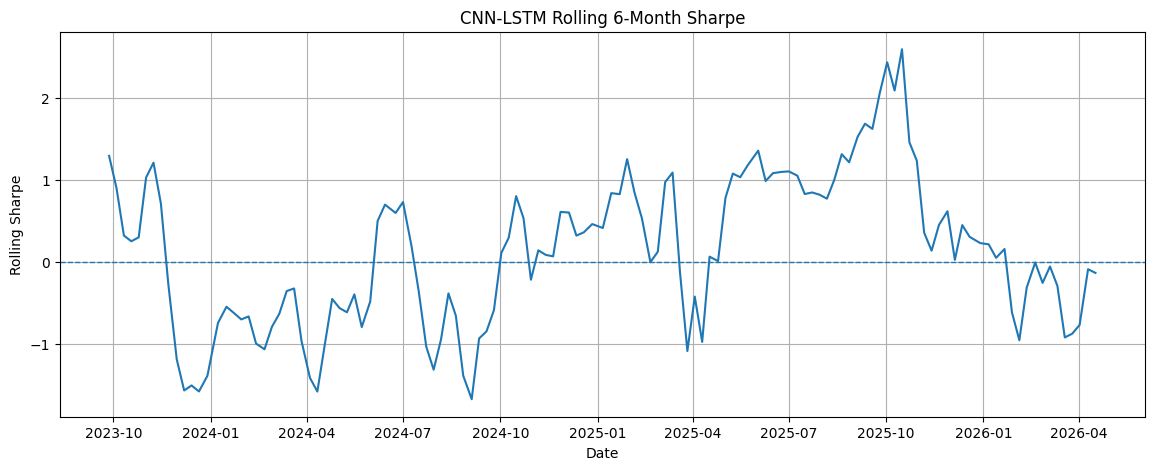

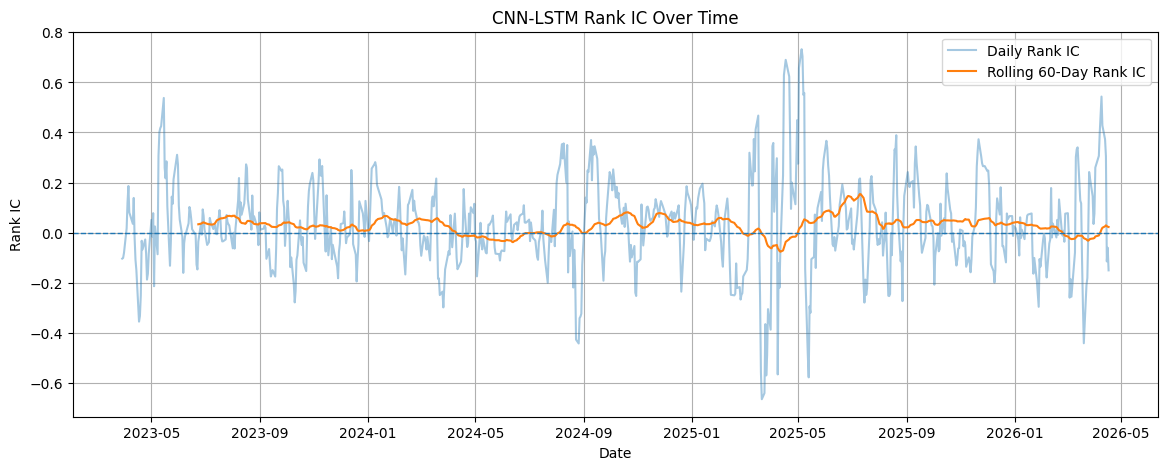

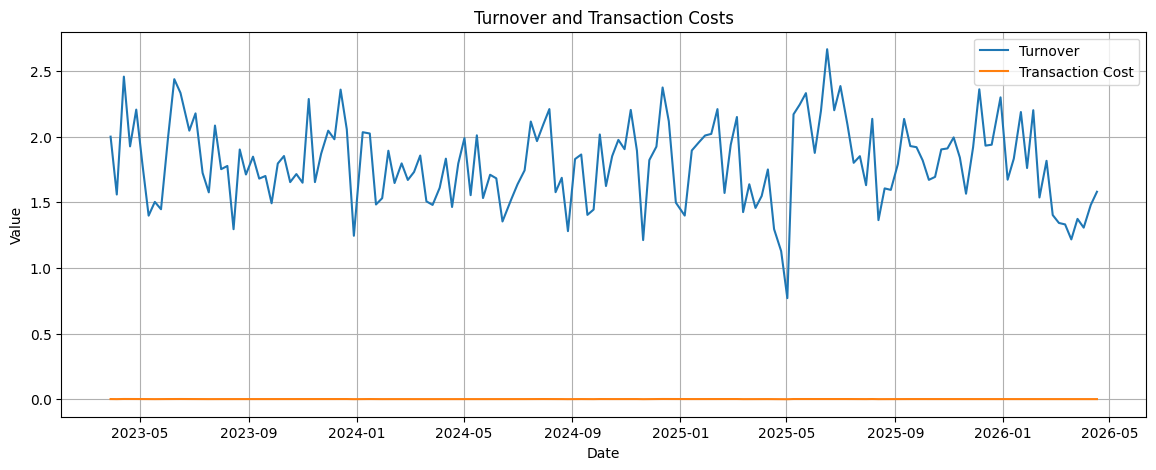

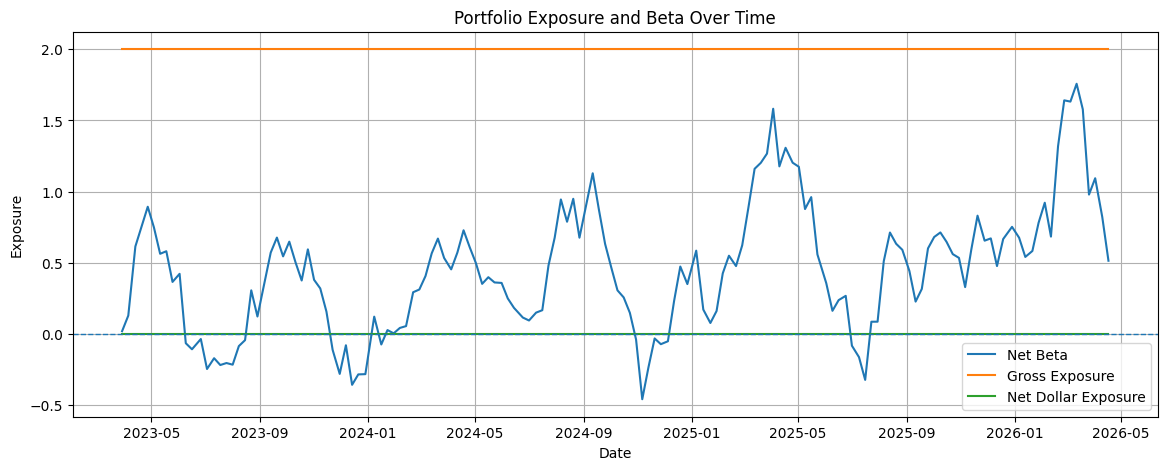

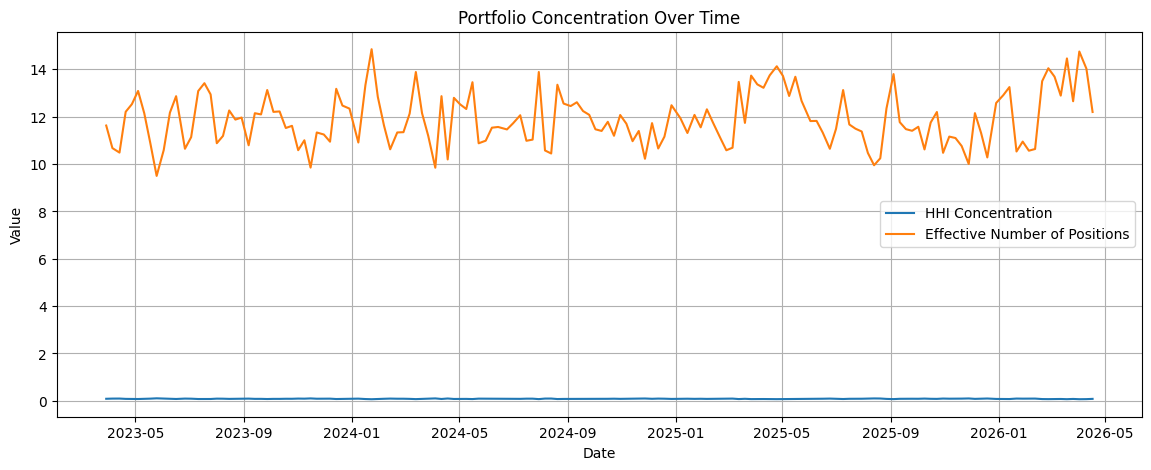

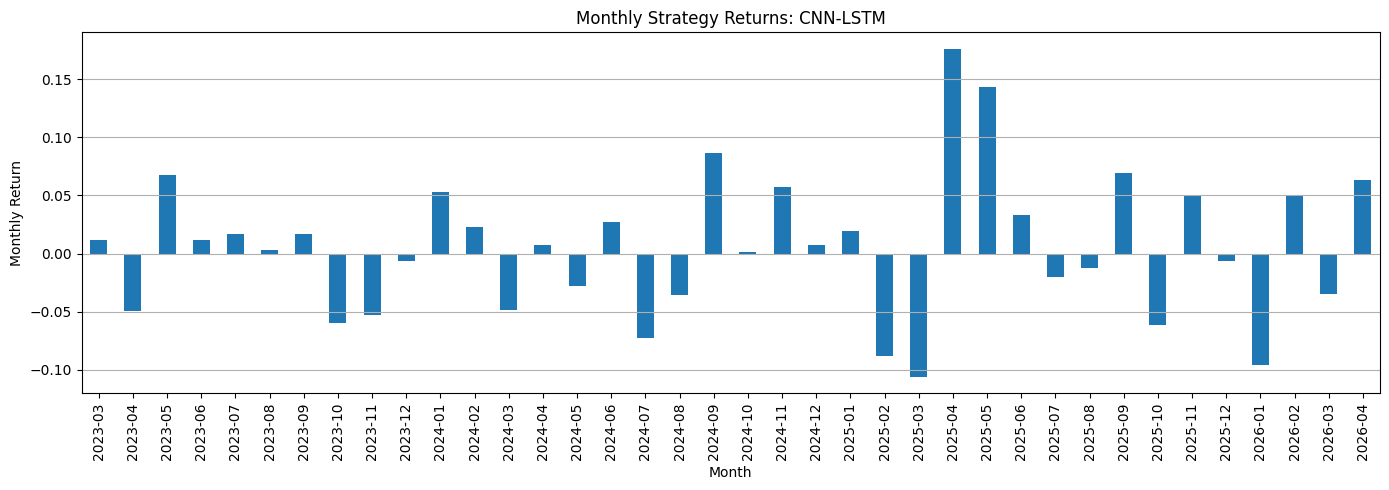

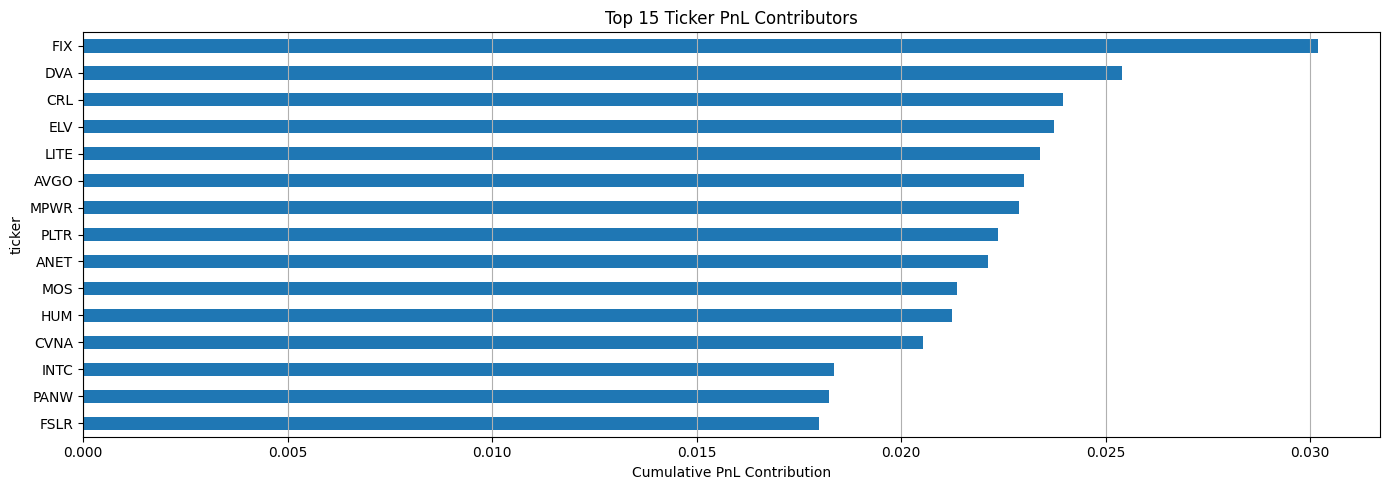

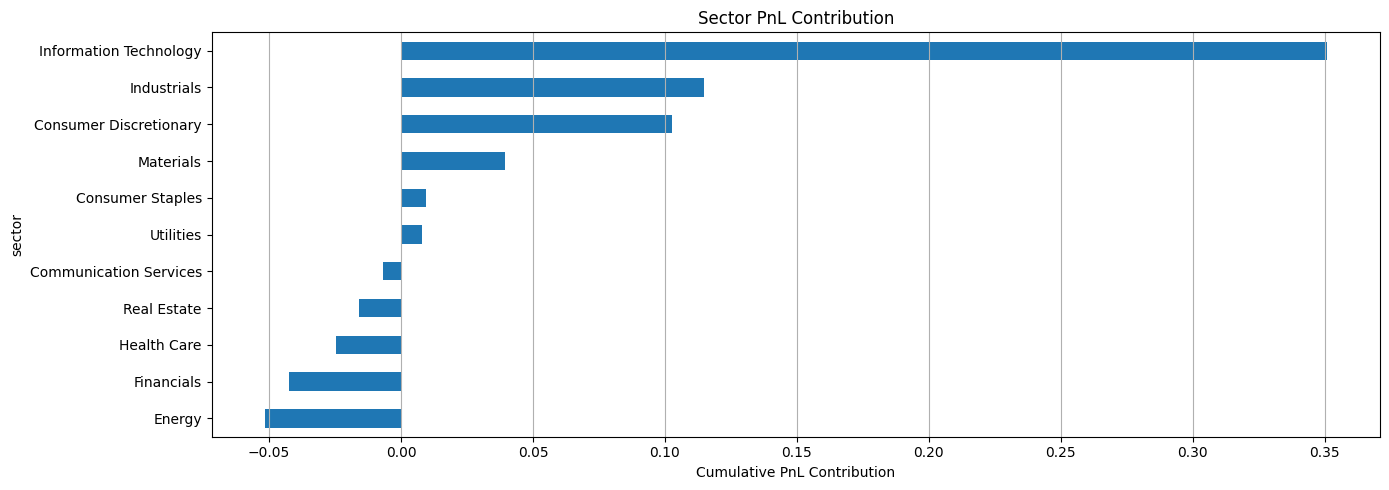


FINAL INTERPRETATION
This version keeps the original 24 model input features but upgrades the research pipeline with a larger universe, explicit one-day execution lag, stronger baselines, portfolio evolution, rolling IC, yearly performance, turnover/cost analysis, beta/sector exposure diagnostics, contribution analysis, concentration analysis, and a latest live-style portfolio signal.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import requests
from io import StringIO
from scipy import stats

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout, LayerNormalization, Multiply, Flatten, Activation, Reshape, Lambda
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except:
    HAS_XGB = False

tf.random.set_seed(42)
np.random.seed(42)

START_DATE = "2014-01-01"
END_DATE = pd.Timestamp.today().strftime("%Y-%m-%d")
LOOKBACK = 60
HORIZON = 5
TRADE_LAG = 1
MAX_TICKERS = None
TRAIN_END = "2020-12-31"
VAL_END = "2022-12-31"
LONG_Q = 0.90
SHORT_Q = 0.10
REBALANCE_EVERY = 5
TRANSACTION_COST = 0.001
MAX_POSITION = 0.08
ROLLING_WINDOW = 26

print("=" * 80)
print("ORIGINAL-FEATURE ALPHA MODEL WITH PROFESSIONAL BACKTESTING EXTENSIONS")
print("=" * 80)

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
response.raise_for_status()
tables = pd.read_html(StringIO(response.text))
sp500_table = tables[0].copy()
sp500_table["ticker"] = sp500_table["Symbol"].str.replace(".", "-", regex=False)
sector_map = sp500_table.set_index("ticker")["GICS Sector"].to_dict()

tickers = sp500_table["ticker"].tolist()
if MAX_TICKERS is not None:
    tickers = tickers[:MAX_TICKERS]

print(f"Downloading {len(tickers)} tickers from {START_DATE} to {END_DATE}...")

raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    group_by="column",
    progress=False,
    threads=True
)

def yahoo_to_long(raw):
    if isinstance(raw.columns, pd.MultiIndex):
        df = raw.stack(level=1).reset_index()
    else:
        df = raw.copy().reset_index()
        df["ticker"] = tickers[0]
    df.columns = [str(c).lower().replace(" ", "_") for c in df.columns]
    if "level_1" in df.columns:
        df = df.rename(columns={"level_1": "ticker"})
    if "price" in df.columns:
        df = df.drop(columns=["price"])
    needed = ["date", "ticker", "open", "high", "low", "close", "adj_close", "volume"]
    df = df[[c for c in needed if c in df.columns]]
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)
    return df

df = yahoo_to_long(raw)
df["sector"] = df["ticker"].map(sector_map).fillna("Unknown")
df = df.dropna(subset=["adj_close", "close", "volume"])
df = df[(df["adj_close"] > 0) & (df["close"] > 0) & (df["volume"] > 0)]
counts = df.groupby("ticker")["date"].count()
valid_tickers = counts[counts >= 1000].index.tolist()
df = df[df["ticker"].isin(valid_tickers)].copy()
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

spy = yf.download("SPY", start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)
spy = spy.reset_index()
spy.columns = [str(c).lower().replace(" ", "_") for c in spy.columns]
price_col = "adj_close" if "adj_close" in spy.columns else "close"
spy = spy[["date", price_col]].copy()
spy = spy.rename(columns={price_col: "spy_adj_close"})
spy["spy_ret_1d"] = spy["spy_adj_close"].pct_change(1)
spy["spy_ret_5d"] = spy["spy_adj_close"].pct_change(5)
spy["spy_ret_21d"] = spy["spy_adj_close"].pct_change(21)
spy["spy_ret_63d"] = spy["spy_adj_close"].pct_change(63)
spy["spy_vol_21d"] = spy["spy_ret_1d"].rolling(21).std()

df = df.merge(
    spy[["date", "spy_ret_1d", "spy_ret_5d", "spy_ret_21d", "spy_ret_63d", "spy_vol_21d"]],
    on="date",
    how="left"
)

def add_features(data):
    data = data.sort_values(["ticker", "date"]).copy()
    g = data.groupby("ticker", group_keys=False)

    data["ret_1d"] = g["adj_close"].pct_change(1)
    data["ret_5d"] = g["adj_close"].pct_change(5)
    data["ret_10d"] = g["adj_close"].pct_change(10)
    data["ret_21d"] = g["adj_close"].pct_change(21)
    data["ret_63d"] = g["adj_close"].pct_change(63)

    data["vol_5d"] = g["ret_1d"].rolling(5).std().reset_index(level=0, drop=True)
    data["vol_21d"] = g["ret_1d"].rolling(21).std().reset_index(level=0, drop=True)
    data["vol_63d"] = g["ret_1d"].rolling(63).std().reset_index(level=0, drop=True)

    data["sma_10"] = g["adj_close"].rolling(10).mean().reset_index(level=0, drop=True)
    data["sma_21"] = g["adj_close"].rolling(21).mean().reset_index(level=0, drop=True)
    data["sma_63"] = g["adj_close"].rolling(63).mean().reset_index(level=0, drop=True)

    data["price_to_sma_10"] = data["adj_close"] / data["sma_10"] - 1
    data["price_to_sma_21"] = data["adj_close"] / data["sma_21"] - 1
    data["price_to_sma_63"] = data["adj_close"] / data["sma_63"] - 1

    data["volume_chg_1d"] = g["volume"].pct_change(1)
    data["volume_sma_21"] = g["volume"].rolling(21).mean().reset_index(level=0, drop=True)
    data["volume_to_sma_21"] = data["volume"] / data["volume_sma_21"] - 1

    data["dollar_volume"] = data["adj_close"] * data["volume"]
    data["dollar_volume_sma_21"] = g["dollar_volume"].rolling(21).mean().reset_index(level=0, drop=True)
    data["dollar_volume_to_sma_21"] = data["dollar_volume"] / data["dollar_volume_sma_21"] - 1

    data["daily_range"] = (data["high"] - data["low"]) / data["close"]
    data["close_open_ret"] = data["close"] / data["open"] - 1
    data["close_position"] = (data["close"] - data["low"]) / (data["high"] - data["low"] + 1e-8)

    data["excess_ret_1d"] = data["ret_1d"] - data["spy_ret_1d"]
    data["excess_ret_5d"] = data["ret_5d"] - data["spy_ret_5d"]

    data["beta_63"] = (
        g.apply(lambda x: x["ret_1d"].rolling(63).cov(x["spy_ret_1d"]) / (x["spy_ret_1d"].rolling(63).var() + 1e-8))
        .reset_index(level=0, drop=True)
    )

    entry_price = g["adj_close"].shift(-TRADE_LAG)
    exit_price = g["adj_close"].shift(-(TRADE_LAG + HORIZON))
    data["target_5d_exec_lagged"] = exit_price / entry_price - 1

    return data

print("Engineering original 24-feature set...")
df = add_features(df)

rank_cols = ["ret_5d", "ret_21d", "ret_63d", "vol_21d"]
for col in rank_cols:
    df[col + "_rank"] = df.groupby("date")[col].rank(pct=True)

df["target_5d_cs_z"] = df.groupby("date")["target_5d_exec_lagged"].transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))

cs_features = ["price_to_sma_10", "price_to_sma_21", "price_to_sma_63", "vol_21d", "excess_ret_1d"]
for col in cs_features:
    df[f"{col}_cs_z"] = df.groupby("date")[col].transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))

feature_cols = [
    "ret_1d", "ret_5d", "ret_10d", "ret_21d", "ret_63d",
    "vol_5d", "vol_21d", "vol_63d",
    "price_to_sma_10_cs_z", "price_to_sma_21_cs_z", "price_to_sma_63_cs_z",
    "vol_21d_cs_z", "excess_ret_1d_cs_z",
    "volume_chg_1d", "volume_to_sma_21", "dollar_volume_to_sma_21",
    "daily_range", "close_open_ret", "close_position",
    "excess_ret_5d",
    "ret_5d_rank", "ret_21d_rank", "ret_63d_rank", "vol_21d_rank"
]

df_features_live = df.dropna(subset=feature_cols).copy()
df_model = df.dropna(subset=feature_cols + ["target_5d_exec_lagged", "target_5d_cs_z"]).copy()

df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_features_live.replace([np.inf, -np.inf], np.nan, inplace=True)

df_model = df_model.dropna(subset=feature_cols + ["target_5d_exec_lagged", "target_5d_cs_z"]).sort_values(["ticker", "date"]).reset_index(drop=True)
df_features_live = df_features_live.dropna(subset=feature_cols).sort_values(["ticker", "date"]).reset_index(drop=True)

train_df = df_model[df_model["date"] <= TRAIN_END].copy()
val_df = df_model[(df_model["date"] > TRAIN_END) & (df_model["date"] <= VAL_END)].copy()
test_df = df_model[df_model["date"] > VAL_END].copy()

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

for part in [train_df, val_df, test_df, df_features_live]:
    part.loc[:, feature_cols] = scaler.transform(part[feature_cols])

def make_sequences(data, feature_cols, target_col, realized_col, lookback):
    X, y, dates, tickers_out, realized_targets = [], [], [], [], []
    for ticker, sub in data.groupby("ticker"):
        sub = sub.sort_values("date").reset_index(drop=True)
        features = sub[feature_cols].values
        target = sub[target_col].values
        realized = sub[realized_col].values
        sub_dates = sub["date"].values
        for i in range(lookback, len(sub)):
            X.append(features[i - lookback:i])
            y.append(target[i - 1])
            realized_targets.append(realized[i - 1])
            dates.append(sub_dates[i - 1])
            tickers_out.append(ticker)
    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        pd.DataFrame({"date": dates, "ticker": tickers_out, "realized_ret_5d": realized_targets})
    )

def make_live_sequences(data, feature_cols, lookback):
    X, dates, tickers_out = [], [], []
    for ticker, sub in data.groupby("ticker"):
        sub = sub.sort_values("date").reset_index(drop=True)
        if len(sub) < lookback:
            continue
        features = sub[feature_cols].values
        X.append(features[-lookback:])
        dates.append(sub["date"].iloc[-1])
        tickers_out.append(ticker)
    return np.array(X, dtype=np.float32), pd.DataFrame({"date": dates, "ticker": tickers_out})

print("Generating sequences...")
X_train, y_train, meta_train = make_sequences(train_df, feature_cols, "target_5d_cs_z", "target_5d_exec_lagged", LOOKBACK)
X_val, y_val, meta_val = make_sequences(val_df, feature_cols, "target_5d_cs_z", "target_5d_exec_lagged", LOOKBACK)
X_test, y_test, meta_test = make_sequences(test_df, feature_cols, "target_5d_cs_z", "target_5d_exec_lagged", LOOKBACK)
X_live, meta_live = make_live_sequences(df_features_live, feature_cols, LOOKBACK)

print(f"Universe after cleaning: {df_model['ticker'].nunique()} stocks")
print(f"Feature count: {len(feature_cols)}")
print(f"Train sequences: {X_train.shape}")
print(f"Validation sequences: {X_val.shape}")
print(f"Test sequences: {X_test.shape}")
print(f"Live/latest scored stocks: {X_live.shape}")

def build_advanced_model(lookback, num_features):
    inputs = Input(shape=(lookback, num_features))
    x = Conv1D(filters=32, kernel_size=3, padding="same", activation="relu")(inputs)
    x = LayerNormalization()(x)
    lstm_out = LSTM(64, return_sequences=True)(x)
    lstm_out = Dropout(0.2)(lstm_out)
    attention_scores = Dense(1, activation="tanh")(lstm_out)
    attention_scores = Flatten()(attention_scores)
    attention_weights = Activation("softmax", name="attention_weights")(attention_scores)
    attention_weights = Reshape((lookback, 1))(attention_weights)
    attended_seq = Multiply()([lstm_out, attention_weights])
    context_vector = Lambda(lambda z: tf.reduce_sum(z, axis=1))(attended_seq)
    dense = Dense(32, activation="swish")(context_vector)
    dense = Dropout(0.1)(dense)
    outputs = Dense(1)(dense)
    model = Model(inputs=inputs, outputs=outputs, name="CNN_LSTM_Attention")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss=tf.keras.losses.Huber(), metrics=["mae"])
    return model

print("Training CNN-LSTM-Attention model...")
model = build_advanced_model(LOOKBACK, len(feature_cols))
early_stop = EarlyStopping(monitor="val_loss", patience=5, min_delta=1e-4, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

pred_test_lstm = model.predict(X_test, batch_size=512).flatten()
pred_live_lstm = model.predict(X_live, batch_size=512).flatten()

X_train_tab = X_train[:, -1, :]
X_test_tab = X_test[:, -1, :]
X_live_tab = X_live[:, -1, :]

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_tab, y_train)
pred_test_ridge = ridge.predict(X_test_tab)
pred_live_ridge = ridge.predict(X_live_tab)

if HAS_XGB:
    tree_model = XGBRegressor(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
else:
    tree_model = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=42
    )

print("Training tree baseline...")
tree_model.fit(X_train_tab, y_train)
pred_test_tree = tree_model.predict(X_test_tab)
pred_live_tree = tree_model.predict(X_live_tab)

meta_test_lstm = meta_test.copy()
meta_test_ridge = meta_test.copy()
meta_test_tree = meta_test.copy()

meta_test_lstm["pred_ret_5d"] = pred_test_lstm
meta_test_ridge["pred_ret_5d"] = pred_test_ridge
meta_test_tree["pred_ret_5d"] = pred_test_tree

baseline_tab = test_df[["date", "ticker", "ret_21d", "ret_5d", "target_5d_exec_lagged"]].dropna().rename(columns={"target_5d_exec_lagged": "realized_ret_5d"})
meta_test_mom = baseline_tab[["date", "ticker", "realized_ret_5d"]].copy()
meta_test_mom["pred_ret_5d"] = baseline_tab["ret_21d"]
meta_test_mr = baseline_tab[["date", "ticker", "realized_ret_5d"]].copy()
meta_test_mr["pred_ret_5d"] = -baseline_tab["ret_5d"]

def rank_ic_series(pred_df):
    return pred_df.groupby("date").apply(
        lambda x: x["pred_ret_5d"].corr(x["realized_ret_5d"], method="spearman") if len(x) >= 10 else np.nan
    ).dropna()

def ic_summary(pred_df):
    ic = rank_ic_series(pred_df)
    return pd.Series({
        "Mean Rank IC": ic.mean(),
        "IC Std": ic.std(),
        "IC t-stat": ic.mean() / (ic.std() / np.sqrt(len(ic))) if len(ic) > 1 and ic.std() > 0 else np.nan,
        "Positive IC %": (ic > 0).mean(),
        "IC Count": len(ic)
    })

ic_table = pd.DataFrame({
    "CNN-LSTM-Attn": ic_summary(meta_test_lstm),
    "Ridge": ic_summary(meta_test_ridge),
    "Tree/XGBoost": ic_summary(meta_test_tree),
    "Momentum": ic_summary(meta_test_mom),
    "Mean Reversion": ic_summary(meta_test_mr)
})

print("\n" + "=" * 80)
print("RANK IC DIAGNOSTICS")
print("=" * 80)
print(ic_table.round(4))

def capped_normalize(side_df, sign=1, max_position=0.08):
    w = side_df["raw_weight"].values.astype(float)
    w = w / (w.sum() + 1e-12)
    for _ in range(10):
        w = np.minimum(w, max_position)
        w = w / (w.sum() + 1e-12)
    return sign * w

def build_portfolio_history(pred_df, feature_df, long_q=0.90, short_q=0.10, rebalance_every=5, cost=0.001, max_position=0.08):
    enrich_cols = ["date", "ticker", "sector", "vol_21d", "beta_63", "dollar_volume_sma_21", "ret_21d", "ret_63d", "excess_ret_5d"]
    available_cols = [c for c in enrich_cols if c in feature_df.columns]
    pred_df = pred_df.merge(feature_df[available_cols].drop_duplicates(["date", "ticker"]), on=["date", "ticker"], how="left")

    dates = sorted(pred_df["date"].unique())
    rebalance_dates = dates[::rebalance_every]
    portfolio_rows = []
    holding_rows = []
    prev_weights = pd.Series(dtype=float)

    for d in rebalance_dates:
        day_data = pred_df[pred_df["date"] == d].copy()
        if len(day_data) < 20:
            continue

        long_cut = day_data["pred_ret_5d"].quantile(long_q)
        short_cut = day_data["pred_ret_5d"].quantile(short_q)

        longs = day_data[day_data["pred_ret_5d"] >= long_cut].copy()
        shorts = day_data[day_data["pred_ret_5d"] <= short_cut].copy()

        if len(longs) == 0 or len(shorts) == 0:
            continue

        longs["side"] = "Long"
        shorts["side"] = "Short"

        longs["raw_weight"] = 1.0 / (longs["vol_21d"].abs() + 1e-6)
        shorts["raw_weight"] = 1.0 / (shorts["vol_21d"].abs() + 1e-6)

        longs["weight"] = capped_normalize(longs, sign=1, max_position=max_position)
        shorts["weight"] = capped_normalize(shorts, sign=-1, max_position=max_position)

        positions = pd.concat([longs, shorts], axis=0).copy()
        target_weights = positions.set_index("ticker")["weight"]

        turnover = target_weights.sub(prev_weights, fill_value=0).abs().sum()
        tc = cost * turnover

        positions["pnl_contribution"] = positions["weight"] * positions["realized_ret_5d"]

        long_return = positions.loc[positions["weight"] > 0, "pnl_contribution"].sum()
        short_return = positions.loc[positions["weight"] < 0, "pnl_contribution"].sum()
        gross_return = positions["pnl_contribution"].sum()
        net_return = gross_return - tc

        gross_exposure = positions["weight"].abs().sum()
        net_exposure = positions["weight"].sum()
        long_exposure = positions.loc[positions["weight"] > 0, "weight"].sum()
        short_exposure = positions.loc[positions["weight"] < 0, "weight"].sum()

        net_beta = (positions["weight"] * positions["beta_63"].fillna(0)).sum()
        long_beta = (positions.loc[positions["weight"] > 0, "weight"] * positions.loc[positions["weight"] > 0, "beta_63"].fillna(0)).sum()
        short_beta = (positions.loc[positions["weight"] < 0, "weight"] * positions.loc[positions["weight"] < 0, "beta_63"].fillna(0)).sum()

        concentration_hhi = (positions["weight"].abs() ** 2).sum()
        effective_positions = 1 / concentration_hhi if concentration_hhi > 0 else np.nan

        portfolio_rows.append({
            "date": d,
            "gross_return": gross_return,
            "net_return": net_return,
            "long_return": long_return,
            "short_return": short_return,
            "transaction_cost": tc,
            "turnover": turnover,
            "gross_exposure": gross_exposure,
            "net_exposure": net_exposure,
            "long_exposure": long_exposure,
            "short_exposure": short_exposure,
            "net_beta": net_beta,
            "long_beta": long_beta,
            "short_beta": short_beta,
            "n_long": (positions["side"] == "Long").sum(),
            "n_short": (positions["side"] == "Short").sum(),
            "concentration_hhi": concentration_hhi,
            "effective_positions": effective_positions,
            "largest_long": positions["weight"].max(),
            "largest_short": positions["weight"].min(),
            "avg_pred_long": positions.loc[positions["side"] == "Long", "pred_ret_5d"].mean(),
            "avg_pred_short": positions.loc[positions["side"] == "Short", "pred_ret_5d"].mean(),
            "avg_realized_long": positions.loc[positions["side"] == "Long", "realized_ret_5d"].mean(),
            "avg_realized_short": positions.loc[positions["side"] == "Short", "realized_ret_5d"].mean()
        })

        for _, row in positions.iterrows():
            holding_rows.append({
                "date": d,
                "ticker": row["ticker"],
                "sector": row.get("sector", "Unknown"),
                "side": row["side"],
                "weight": row["weight"],
                "pred_score": row["pred_ret_5d"],
                "realized_ret_5d": row["realized_ret_5d"],
                "pnl_contribution": row["pnl_contribution"],
                "vol_21d": row.get("vol_21d", np.nan),
                "beta_63": row.get("beta_63", np.nan),
                "dollar_volume_sma_21": row.get("dollar_volume_sma_21", np.nan)
            })

        prev_weights = target_weights

    portfolio_history = pd.DataFrame(portfolio_rows)
    holdings_history = pd.DataFrame(holding_rows)

    if len(portfolio_history) > 0:
        portfolio_history["cum_return"] = (1 + portfolio_history["net_return"]).cumprod()
        portfolio_history["cum_long"] = (1 + portfolio_history["long_return"]).cumprod()
        portfolio_history["cum_short"] = (1 + portfolio_history["short_return"]).cumprod()
        portfolio_history["running_max"] = portfolio_history["cum_return"].cummax()
        portfolio_history["drawdown"] = portfolio_history["cum_return"] / portfolio_history["running_max"] - 1
        portfolio_history["rolling_return"] = portfolio_history["net_return"].rolling(ROLLING_WINDOW).apply(lambda x: (1 + x).prod() - 1)
        portfolio_history["rolling_vol"] = portfolio_history["net_return"].rolling(ROLLING_WINDOW).std() * np.sqrt(252 / rebalance_every)
        portfolio_history["rolling_sharpe"] = (
            portfolio_history["net_return"].rolling(ROLLING_WINDOW).mean() * (252 / rebalance_every)
        ) / portfolio_history["rolling_vol"]

    return portfolio_history, holdings_history

def performance_summary(bt, return_col="net_return", periods_per_year=252 / REBALANCE_EVERY):
    if len(bt) == 0:
        return pd.Series(dtype=float)
    r = bt[return_col].dropna()
    ann_return = (1 + r).prod() ** (periods_per_year / len(r)) - 1
    ann_vol = r.std() * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    cumulative = (1 + r).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    t_stat = r.mean() / (r.std() / np.sqrt(len(r))) if len(r) > 1 and r.std() > 0 else np.nan
    return pd.Series({
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Return t-stat": t_stat,
        "Max Drawdown": drawdown.min(),
        "Hit Rate": (r > 0).mean(),
        "Average Turnover": bt["turnover"].mean() if "turnover" in bt.columns else np.nan,
        "Average Net Beta": bt["net_beta"].mean() if "net_beta" in bt.columns else np.nan,
        "Average Gross Exposure": bt["gross_exposure"].mean() if "gross_exposure" in bt.columns else np.nan,
        "Average Effective Positions": bt["effective_positions"].mean() if "effective_positions" in bt.columns else np.nan
    })

print("Running portfolio backtests...")
bt_lstm, holdings_lstm = build_portfolio_history(meta_test_lstm, test_df, LONG_Q, SHORT_Q, REBALANCE_EVERY, TRANSACTION_COST, MAX_POSITION)
bt_ridge, holdings_ridge = build_portfolio_history(meta_test_ridge, test_df, LONG_Q, SHORT_Q, REBALANCE_EVERY, TRANSACTION_COST, MAX_POSITION)
bt_tree, holdings_tree = build_portfolio_history(meta_test_tree, test_df, LONG_Q, SHORT_Q, REBALANCE_EVERY, TRANSACTION_COST, MAX_POSITION)
bt_mom, holdings_mom = build_portfolio_history(meta_test_mom, test_df, LONG_Q, SHORT_Q, REBALANCE_EVERY, TRANSACTION_COST, MAX_POSITION)
bt_mr, holdings_mr = build_portfolio_history(meta_test_mr, test_df, LONG_Q, SHORT_Q, REBALANCE_EVERY, TRANSACTION_COST, MAX_POSITION)

comparison = pd.DataFrame({
    "CNN-LSTM-Attn": performance_summary(bt_lstm),
    "Ridge": performance_summary(bt_ridge),
    "Tree/XGBoost": performance_summary(bt_tree),
    "Momentum": performance_summary(bt_mom),
    "Mean Reversion": performance_summary(bt_mr)
})

print("\n" + "=" * 80)
print("BACKTEST PERFORMANCE SUMMARY")
print("=" * 80)
print(comparison.round(4))

def yearly_performance(bt):
    temp = bt.copy()
    temp["year"] = temp["date"].dt.year
    rows = []
    for year, sub in temp.groupby("year"):
        s = performance_summary(sub)
        s["Year"] = year
        rows.append(s)
    return pd.DataFrame(rows).set_index("Year")

print("\n" + "=" * 80)
print("YEARLY PERFORMANCE: CNN-LSTM-ATTENTION")
print("=" * 80)
yearly_lstm = yearly_performance(bt_lstm)
print(yearly_lstm.round(4))

ic_lstm = rank_ic_series(meta_test_lstm).rename("rank_ic").reset_index()
ic_lstm["rolling_ic"] = ic_lstm["rank_ic"].rolling(60).mean()
ic_lstm["rolling_ic_tstat"] = ic_lstm["rank_ic"].rolling(60).apply(lambda x: x.mean() / (x.std() / np.sqrt(len(x))) if x.std() > 0 else np.nan)

print("\n" + "=" * 80)
print("ROLLING IC SUMMARY")
print("=" * 80)
print(ic_lstm[["date", "rank_ic", "rolling_ic", "rolling_ic_tstat"]].tail(10).round(4))

sector_exposure = holdings_lstm.groupby(["date", "sector"])["weight"].sum().reset_index()
avg_sector_exposure = sector_exposure.groupby("sector")["weight"].agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False)
sector_pnl = holdings_lstm.groupby("sector")["pnl_contribution"].sum().sort_values(ascending=False)
ticker_pnl = holdings_lstm.groupby("ticker")["pnl_contribution"].sum().sort_values(ascending=False)

print("\n" + "=" * 80)
print("AVERAGE SECTOR EXPOSURE: CNN-LSTM-ATTENTION")
print("=" * 80)
print(avg_sector_exposure.round(4))

print("\n" + "=" * 80)
print("SECTOR PNL CONTRIBUTION: CNN-LSTM-ATTENTION")
print("=" * 80)
print(sector_pnl.round(4))

print("\n" + "=" * 80)
print("TOP 15 TICKER PNL CONTRIBUTORS")
print("=" * 80)
print(ticker_pnl.head(15).round(4))

print("\n" + "=" * 80)
print("BOTTOM 15 TICKER PNL CONTRIBUTORS")
print("=" * 80)
print(ticker_pnl.tail(15).round(4))

holding_stability = holdings_lstm.groupby("ticker").agg(
    times_held=("date", "count"),
    avg_weight=("weight", "mean"),
    avg_abs_weight=("weight", lambda x: x.abs().mean()),
    cumulative_pnl=("pnl_contribution", "sum"),
    avg_pred_score=("pred_score", "mean"),
    avg_realized_ret=("realized_ret_5d", "mean")
).sort_values("times_held", ascending=False)

print("\n" + "=" * 80)
print("HOLDING STABILITY")
print("=" * 80)
print(holding_stability.head(25).round(4))

meta_live_lstm = meta_live.copy()
meta_live_lstm["pred_ret_5d"] = pred_live_lstm

latest_feature_df = df_features_live.copy()
latest_live = meta_live_lstm.merge(
    latest_feature_df[["date", "ticker", "sector", "vol_21d", "beta_63", "dollar_volume_sma_21"]].drop_duplicates(["date", "ticker"]),
    on=["date", "ticker"],
    how="left"
)

latest_date = latest_live["date"].max()
latest_live = latest_live[latest_live["date"] == latest_date].copy()
long_cut = latest_live["pred_ret_5d"].quantile(LONG_Q)
short_cut = latest_live["pred_ret_5d"].quantile(SHORT_Q)

latest_longs = latest_live[latest_live["pred_ret_5d"] >= long_cut].copy()
latest_shorts = latest_live[latest_live["pred_ret_5d"] <= short_cut].copy()

latest_longs["side"] = "Long"
latest_shorts["side"] = "Short"

latest_longs["raw_weight"] = 1.0 / (latest_longs["vol_21d"].abs() + 1e-6)
latest_shorts["raw_weight"] = 1.0 / (latest_shorts["vol_21d"].abs() + 1e-6)

latest_longs["weight"] = capped_normalize(latest_longs, 1, MAX_POSITION)
latest_shorts["weight"] = capped_normalize(latest_shorts, -1, MAX_POSITION)

latest_portfolio = pd.concat([latest_longs, latest_shorts], axis=0).sort_values("weight", ascending=False)

print("\n" + "=" * 80)
print(f"LATEST LIVE-STYLE MODEL PORTFOLIO SIGNAL: {pd.to_datetime(latest_date).strftime('%Y-%m-%d')}")
print("=" * 80)
print(latest_portfolio[["ticker", "sector", "side", "pred_ret_5d", "weight", "vol_21d", "beta_63", "dollar_volume_sma_21"]].round(4))

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE: RIDGE AND TREE MODEL")
print("=" * 80)

ridge_importance = pd.Series(np.abs(ridge.coef_), index=feature_cols).sort_values(ascending=False)
print("\nTop Ridge Features:")
print(ridge_importance.head(24).round(4))

sample_n = min(5000, len(X_test_tab))
sample_idx = np.random.choice(len(X_test_tab), size=sample_n, replace=False)

try:
    perm = permutation_importance(
        tree_model,
        X_test_tab[sample_idx],
        y_test[sample_idx],
        n_repeats=3,
        random_state=42,
        n_jobs=-1
    )
    perm_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
    print("\nTop Tree Permutation Features:")
    print(perm_importance.head(24).round(6))
except Exception as e:
    print("\nPermutation importance skipped:", e)

plt.figure(figsize=(14, 6))
plt.plot(bt_lstm["date"], bt_lstm["cum_return"], label="CNN-LSTM-Attn")
plt.plot(bt_ridge["date"], bt_ridge["cum_return"], label="Ridge", alpha=0.8)
plt.plot(bt_tree["date"], bt_tree["cum_return"], label="Tree/XGBoost", alpha=0.8)
plt.plot(bt_mom["date"], bt_mom["cum_return"], label="Momentum", alpha=0.7)
plt.plot(bt_mr["date"], bt_mr["cum_return"], label="Mean Reversion", alpha=0.7)
plt.title("Out-of-Sample Portfolio Evolution")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(bt_lstm["date"], bt_lstm["cum_return"], label="Total Net Portfolio")
plt.plot(bt_lstm["date"], bt_lstm["cum_long"], label="Long Book")
plt.plot(bt_lstm["date"], bt_lstm["cum_short"], label="Short Book")
plt.title("CNN-LSTM Portfolio Evolution: Total, Long Book, Short Book")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(bt_lstm["date"], bt_lstm["drawdown"])
plt.title("CNN-LSTM Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(bt_lstm["date"], bt_lstm["rolling_sharpe"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("CNN-LSTM Rolling 6-Month Sharpe")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(ic_lstm["date"], ic_lstm["rank_ic"], alpha=0.4, label="Daily Rank IC")
plt.plot(ic_lstm["date"], ic_lstm["rolling_ic"], label="Rolling 60-Day Rank IC")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("CNN-LSTM Rank IC Over Time")
plt.xlabel("Date")
plt.ylabel("Rank IC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(bt_lstm["date"], bt_lstm["turnover"], label="Turnover")
plt.plot(bt_lstm["date"], bt_lstm["transaction_cost"], label="Transaction Cost")
plt.title("Turnover and Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(bt_lstm["date"], bt_lstm["net_beta"], label="Net Beta")
plt.plot(bt_lstm["date"], bt_lstm["gross_exposure"], label="Gross Exposure")
plt.plot(bt_lstm["date"], bt_lstm["net_exposure"], label="Net Dollar Exposure")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Portfolio Exposure and Beta Over Time")
plt.xlabel("Date")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(bt_lstm["date"], bt_lstm["concentration_hhi"], label="HHI Concentration")
plt.plot(bt_lstm["date"], bt_lstm["effective_positions"], label="Effective Number of Positions")
plt.title("Portfolio Concentration Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

monthly = bt_lstm.copy()
monthly["month"] = monthly["date"].dt.to_period("M").astype(str)
monthly_returns = monthly.groupby("month")["net_return"].apply(lambda x: (1 + x).prod() - 1)

plt.figure(figsize=(14, 5))
monthly_returns.plot(kind="bar")
plt.title("Monthly Strategy Returns: CNN-LSTM")
plt.xlabel("Month")
plt.ylabel("Monthly Return")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
ticker_pnl.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Ticker PnL Contributors")
plt.xlabel("Cumulative PnL Contribution")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
sector_pnl.sort_values().plot(kind="barh")
plt.title("Sector PnL Contribution")
plt.xlabel("Cumulative PnL Contribution")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("FINAL INTERPRETATION")
print("=" * 80)
print("This version keeps the original 24 model input features but upgrades the research pipeline with a larger universe, explicit one-day execution lag, stronger baselines, portfolio evolution, rolling IC, yearly performance, turnover/cost analysis, beta/sector exposure diagnostics, contribution analysis, concentration analysis, and a latest live-style portfolio signal.")

In [2]:
meta_test_lstm[["date", "ticker", "pred_ret_5d", "realized_ret_5d"]].to_csv(
    "lstm_preds_sp500.csv", index=False
)
from google.colab import files
files.download("lstm_preds_sp500.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PERIODS_PER_YEAR = 252 / REBALANCE_EVERY
RF_ANNUAL        = 0.0
STRATEGY         = "CNN-LSTM-Attn"
PLOT_DIR         = "eval_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

print(f"REBALANCE_EVERY = {REBALANCE_EVERY}  ->  PERIODS_PER_YEAR = {PERIODS_PER_YEAR:.2f}")


REBALANCE_EVERY = 5  ->  PERIODS_PER_YEAR = 50.40


In [3]:
STRATEGY_BT = {
    "CNN-LSTM-Attn": bt_lstm,
    "Ridge":         bt_ridge,
    "Tree/XGBoost":  bt_tree,
    "Momentum":      bt_mom,
    "Mean Reversion": bt_mr,
}
STRATEGY_HOLDINGS = {
    "CNN-LSTM-Attn":  holdings_lstm,
    "Ridge":          holdings_ridge,
    "Tree/XGBoost":   holdings_tree,
    "Momentum":       holdings_mom,
    "Mean Reversion": holdings_mr,
}

bt_df       = STRATEGY_BT[STRATEGY].copy()
holdings_df = STRATEGY_HOLDINGS[STRATEGY].copy()

# Ensure datetime index on returns
bt_df["date"]       = pd.to_datetime(bt_df["date"])
holdings_df["date"] = pd.to_datetime(holdings_df["date"])

# r = portfolio return series at 5-day rebalance frequency
r = bt_df.set_index("date")["net_return"].astype(float).dropna()

# w = wide weights (date x ticker), built from long-format holdings
w = (holdings_df.pivot_table(index="date", columns="ticker",
                             values="weight", fill_value=0.0)
                .reindex(r.index, fill_value=0.0))

# REBAL = list of rebalance dates (every row in bt_df IS a rebalance)
REBAL = pd.DatetimeIndex(r.index)

print(f"{STRATEGY}:  {len(r)} rebalance observations "
      f"({r.index.min().date()}  ->  {r.index.max().date()})")
print(f"Universe touched: {w.shape[1]} unique tickers")


CNN-LSTM-Attn:  153 rebalance observations (2023-03-29  ->  2026-04-10)
Universe touched: 495 unique tickers


In [4]:
spy_df = spy.copy()
spy_df["date"] = pd.to_datetime(spy_df["date"])
spy_daily = spy_df.set_index("date")["spy_ret_1d"].astype(float).dropna()

# Compound daily SPY returns into the same 5-day buckets the strategy uses.
# For each rebalance date r.index[i], take the daily SPY returns from
# r.index[i-1]+1 day  through  r.index[i].
bench_buckets = []
prev = None
for d in r.index:
    if prev is None:
        bench_buckets.append(np.nan)
    else:
        chunk = spy_daily.loc[(spy_daily.index > prev) & (spy_daily.index <= d)]
        bench_buckets.append((1 + chunk).prod() - 1 if len(chunk) else 0.0)
    prev = d

b = pd.Series(bench_buckets, index=r.index, name="benchmark").fillna(0.0)
print(f"Benchmark aligned: {b.notna().sum()} bucketed observations")

try:
    TICKER_PNL = ticker_pnl
except NameError:
    TICKER_PNL = holdings_df.groupby("ticker")["pnl_contribution"].sum().sort_values(ascending=False)


Benchmark aligned: 153 bucketed observations


In [5]:
def period_metrics(r: pd.Series, periods_per_year: float = PERIODS_PER_YEAR) -> pd.Series:
    eq = (1 + r).cumprod()
    n  = len(r)
    years = n / periods_per_year

    total_ret = eq.iloc[-1] - 1.0
    ann_ret   = (1 + total_ret) ** (1 / years) - 1
    ann_vol   = r.std() * np.sqrt(periods_per_year)
    rf_p      = RF_ANNUAL / periods_per_year
    sharpe    = (r.mean() - rf_p) / r.std() * np.sqrt(periods_per_year)

    downside  = r[r < 0]
    dd_dev    = downside.std() * np.sqrt(periods_per_year) if len(downside) else np.nan
    sortino   = ((r.mean() - rf_p) / downside.std() * np.sqrt(periods_per_year)
                 if len(downside) else np.nan)

    running   = eq.cummax()
    dd_series = eq / running - 1.0
    max_dd    = dd_series.min()
    calmar    = ann_ret / abs(max_dd) if max_dd < 0 else np.nan

    skew  = stats.skew(r, bias=False)
    kurt  = stats.kurtosis(r, fisher=True, bias=False)
    ulcer = np.sqrt((dd_series ** 2).mean())

    trough  = dd_series.idxmin()
    peak    = eq.loc[:trough].idxmax()
    after   = eq.loc[trough:]
    rec_pts = after[after >= eq.loc[peak]]
    recovery_periods = (rec_pts.index[0] - trough).days if len(rec_pts) else np.nan

    return pd.Series({
        "Total return":              total_ret,
        "Annualized return":         ann_ret,
        "Annualized volatility":     ann_vol,
        "Sharpe ratio":              sharpe,
        "Sortino ratio":             sortino,
        "Max drawdown":              max_dd,
        "Calmar ratio":              calmar,
        "Skewness (per-period)":     skew,
        "Excess kurtosis":           kurt,
        "Downside deviation (ann.)": dd_dev,
        "Ulcer index":               ulcer,
        "Recovery (calendar days)":  recovery_periods,
    })

period_tbl = period_metrics(r)
period_tbl


,0
Total return,0.400204
Annualized return,0.117268
Annualized volatility,0.193251
Sharpe ratio,0.668868
Sortino ratio,1.165379
Max drawdown,-0.186609
Calmar ratio,0.628414
Skewness (per-period),0.892885
Excess kurtosis,4.388670
Downside deviation (ann.),0.110916


In [6]:
def trade_metrics(holdings_long: pd.DataFrame,
                  weights:      pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    """
    holdings_long: long format with columns date, ticker, side, weight, pnl_contribution
    weights:       wide  date x ticker
    """

    h = holdings_long.copy()
    h["sign"] = np.where(h["side"].str.lower().str.startswith("l"), 1, -1)

    trades = []
    for ticker, grp in h.sort_values(["ticker", "date"]).groupby("ticker"):
        grp = grp.reset_index(drop=True)
        # Detect breaks in continuous holding (gap > 1 rebalance period
        # or sign change opens a new trade)
        new_trade = (grp["date"].diff().dt.days.gt(REBALANCE_EVERY * 2)
                     | grp["sign"].diff().ne(0))
        new_trade.iloc[0] = True
        trade_id = new_trade.cumsum()
        for tid, block in grp.groupby(trade_id):
            trades.append({
                "ticker":       ticker,
                "side":         "Long" if block["sign"].iloc[0] > 0 else "Short",
                "entry":        block["date"].iloc[0],
                "exit":         block["date"].iloc[-1],
                "n_periods":    len(block),
                "holding_days": (block["date"].iloc[-1] - block["date"].iloc[0]).days
                                + REBALANCE_EVERY,
                "avg_weight":   block["weight"].abs().mean(),
                "pnl":          block["pnl_contribution"].sum(),
            })
    trades_df = pd.DataFrame(trades)

    n  = len(trades_df)
    wn = trades_df[trades_df["pnl"] > 0]
    ls = trades_df[trades_df["pnl"] < 0]
    win_rate = len(wn) / n if n else np.nan
    avg_w_   = wn["pnl"].mean() if len(wn) else np.nan
    avg_l_   = ls["pnl"].mean() if len(ls) else np.nan
    pf       = wn["pnl"].sum() / abs(ls["pnl"].sum()) if len(ls) and ls["pnl"].sum() != 0 else np.nan
    avg_hold = trades_df["holding_days"].mean() if n else np.nan

    # Turnover per rebalance: |Δw| summed across the cross-section, averaged over time
    turnover_per_rebal = weights.diff().abs().sum(axis=1).iloc[1:].mean()

    out = pd.Series({
        "Number of trades":              n,
        "Win rate (closed trades)":      win_rate,
        "Average win":                   avg_w_,
        "Average loss":                  avg_l_,
        "Avg win / |Avg loss|":          (avg_w_ / abs(avg_l_)) if avg_l_ else np.nan,
        "Profit factor":                 pf,
        "Average holding period (days)": avg_hold,
        "Avg turnover per rebalance":    turnover_per_rebal,
    })
    return out, trades_df

trade_tbl, trades_df = trade_metrics(holdings_df, w)
trade_tbl


,0
Number of trades,3478.000000
Win rate (closed trades),0.548879
Average win,0.001628
Average loss,-0.001559
Avg win / |Avg loss|,1.044794
Profit factor,1.271199
Average holding period (days),29.785509
Avg turnover per rebalance,1.768225


In [7]:
def risk_metrics(r: pd.Series, w: pd.DataFrame, b: pd.Series,
                 bt_df: pd.DataFrame,
                 periods_per_year: float = PERIODS_PER_YEAR) -> pd.Series:
    # Exposures
    bt_indexed = bt_df.set_index("date")
    gross = bt_indexed["gross_exposure"] if "gross_exposure" in bt_indexed.columns \
            else w.abs().sum(axis=1)
    net   = bt_indexed["net_exposure"]   if "net_exposure"   in bt_indexed.columns \
            else w.sum(axis=1)

    abs_w = w.abs()
    row_sum = abs_w.sum(axis=1).replace(0, np.nan)
    hhi   = (abs_w.div(row_sum, axis=0) ** 2).sum(axis=1).mean()
    top5  = abs_w.div(row_sum, axis=0).apply(
                lambda x: x.nlargest(5).sum(), axis=1).mean()

    # Rolling stats
    if "rolling_vol" in bt_indexed.columns:
        roll_vol_mean = bt_indexed["rolling_vol"].mean()
    else:
        roll_vol_mean = (r.rolling(21).std() * np.sqrt(periods_per_year)).mean()
    if "rolling_sharpe" in bt_indexed.columns:
        roll_sh_mean = bt_indexed["rolling_sharpe"].mean()
    else:
        roll_sh_mean = (r.rolling(21).mean() / r.rolling(21).std()
                        * np.sqrt(periods_per_year)).mean()

    # Beta / alpha / TE / IR vs benchmark
    aligned = pd.concat([r, b], axis=1).dropna()
    if len(aligned) > 2 and aligned.iloc[:,1].std() > 0:
        cov   = np.cov(aligned.iloc[:,0], aligned.iloc[:,1], ddof=1)
        beta  = cov[0, 1] / cov[1, 1]
        alpha_ann = (aligned.iloc[:,0].mean() - beta * aligned.iloc[:,1].mean()) * periods_per_year
        active = aligned.iloc[:,0] - aligned.iloc[:,1]
        te     = active.std() * np.sqrt(periods_per_year)
        ir     = (active.mean() / active.std() * np.sqrt(periods_per_year)
                  if active.std() > 0 else np.nan)
    else:
        beta = alpha_ann = te = ir = np.nan

    var95   = np.quantile(r, 0.05)
    cvar95  = r[r <= var95].mean()
    var99   = np.quantile(r, 0.01)
    cvar99  = r[r <= var99].mean()

    return pd.Series({
        "Average gross exposure":       gross.mean(),
        "Average net exposure":         net.mean(),
        "Average net beta":             bt_indexed["net_beta"].mean()
                                          if "net_beta" in bt_indexed.columns else np.nan,
        "HHI concentration (mean)":     hhi,
        "Top-5 weight share (mean)":    top5,
        "Rolling vol (mean)":           roll_vol_mean,
        "Rolling Sharpe (mean)":        roll_sh_mean,
        "Beta to benchmark":            beta,
        "Annualized alpha":             alpha_ann,
        "Tracking error":               te,
        "Information ratio":            ir,
        "VaR 95% (per-period)":         var95,
        "CVaR 95% (per-period)":        cvar95,
        "VaR 99% (per-period)":         var99,
        "CVaR 99% (per-period)":        cvar99,
    })

risk_tbl = risk_metrics(r, w, b, bt_df)
risk_tbl


,0
Average gross exposure,2.000000e+00
Average net exposure,-3.635975e-17
Average net beta,5.189535e-01
HHI concentration (mean),2.077892e-02
Top-5 weight share (mean),1.982340e-01
Rolling vol (mean),1.841957e-01
Rolling Sharpe (mean),5.034042e-01
Beta to benchmark,-1.382363e-02
Annualized alpha,1.319515e-01
Tracking error,2.336242e-01


In [8]:
def _fmt(s: pd.Series, ints=()) -> pd.Series:
    out = s.copy().astype(object)
    for k, v in s.items():
        if isinstance(v, (int, np.integer)) or k in ints:
            out[k] = f"{int(v):,}" if pd.notna(v) else "—"
        elif any(t in k for t in ("Sharpe","Sortino","ratio","factor","Skew","Kurt",
                                  "Beta","Information","HHI","Top-5","Ulcer",
                                  "exposure","beta","turnover","kurtosis","Skewness")):
            out[k] = f"{v:0.4f}" if pd.notna(v) else "—"
        elif "days" in k.lower() or "Recovery" in k:
            out[k] = f"{v:0.1f}" if pd.notna(v) else "—"
        else:
            out[k] = f"{v:0.4%}" if pd.notna(v) else "—"
    return out

print("=" * 78); print(f"§12.1  PERIOD METRICS  -  {STRATEGY}"); print("=" * 78)
print(_fmt(period_tbl).to_string())

print("\n" + "=" * 78); print(f"§12.2  TRADE METRICS  -  {STRATEGY}"); print("=" * 78)
print(_fmt(trade_tbl, ints=("Number of trades",)).to_string())

print("\n" + "=" * 78); print(f"§12.3  RISK / EXPOSURE METRICS  -  {STRATEGY}"); print("=" * 78)
print(_fmt(risk_tbl).to_string())


§12.1  PERIOD METRICS  -  CNN-LSTM-Attn
Total return                  40.0204%
Annualized return             11.7268%
Annualized volatility         19.3251%
Sharpe ratio                    0.6689
Sortino ratio                   1.1654
Max drawdown                 -18.6609%
Calmar ratio                    0.6284
Skewness (per-period)           0.8929
Excess kurtosis                 4.3887
Downside deviation (ann.)     11.0916%
Ulcer index                     0.0594
Recovery (calendar days)         248.0

§12.2  TRADE METRICS  -  CNN-LSTM-Attn
Number of trades                     3,478
Win rate (closed trades)          54.8879%
Average win                        0.1628%
Average loss                      -0.1559%
Avg win / |Avg loss|             104.4794%
Profit factor                       1.2712
Average holding period (days)         29.8
Avg turnover per rebalance          1.7682

§12.3  RISK / EXPOSURE METRICS  -  CNN-LSTM-Attn
Average gross exposure         2.0000
Average net exposure

In [9]:
def _save(fig, name):
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, f"{name}.png"), dpi=130)
    plt.show()

eq      = (1 + r).cumprod()
eq_b    = (1 + b).cumprod()
running = eq.cummax()
dd      = eq / running - 1.0


### Plot 1 — Equity curve

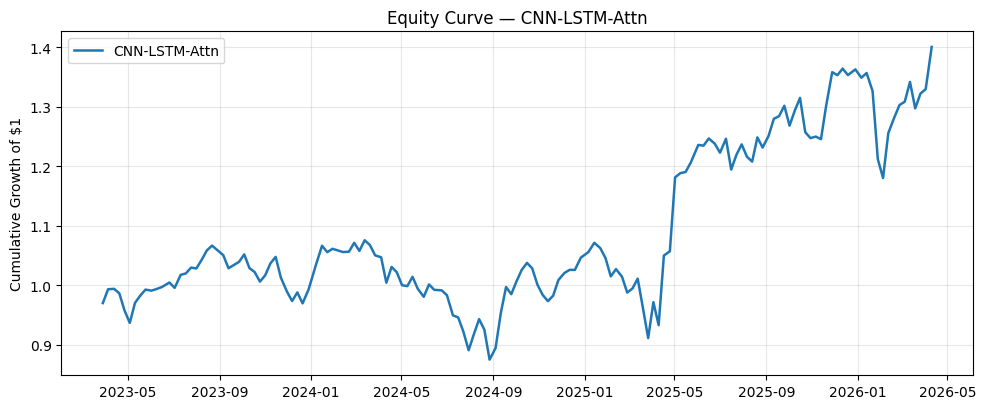

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(eq.index, eq.values, label=STRATEGY, linewidth=1.8)
ax.set_title(f"Equity Curve — {STRATEGY}")
ax.set_ylabel("Cumulative Growth of $1"); ax.grid(alpha=.3); ax.legend()
_save(fig, "01_equity_curve")


### Plot 2 — Drawdown / underwater

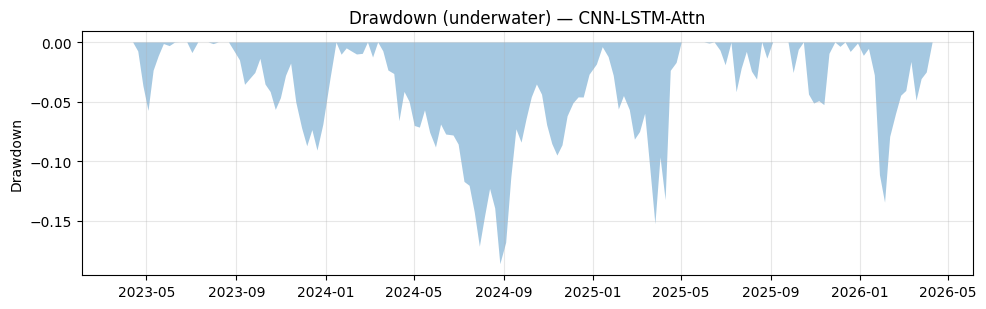

In [11]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.fill_between(dd.index, dd.values, 0, alpha=.4)
ax.set_title(f"Drawdown (underwater) — {STRATEGY}")
ax.set_ylabel("Drawdown"); ax.grid(alpha=.3)
_save(fig, "02_drawdown")


### Plot 3 — Rolling Sharpe (uses existing column if present)

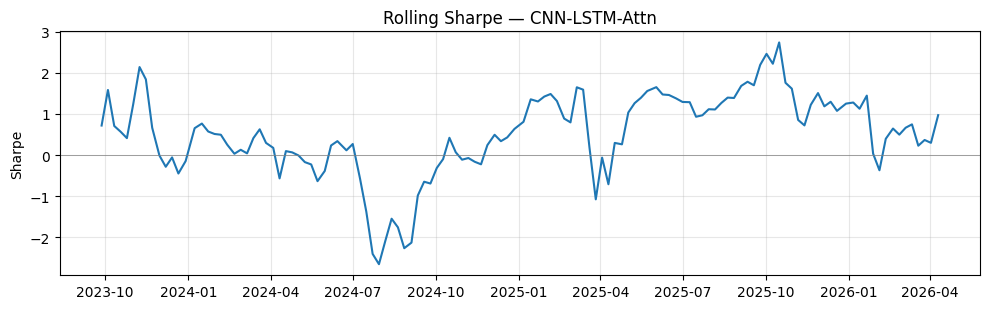

In [12]:
bt_indexed = bt_df.set_index("date")
if "rolling_sharpe" in bt_indexed.columns:
    rs = bt_indexed["rolling_sharpe"].dropna()
else:
    rs = (r.rolling(21).mean() / r.rolling(21).std() * np.sqrt(PERIODS_PER_YEAR)).dropna()
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(rs.index, rs.values)
ax.axhline(0, color="grey", lw=0.5)
ax.set_title(f"Rolling Sharpe — {STRATEGY}")
ax.set_ylabel("Sharpe"); ax.grid(alpha=.3)
_save(fig, "03_rolling_sharpe")


### Plot 4 — Rolling volatility (annualized)

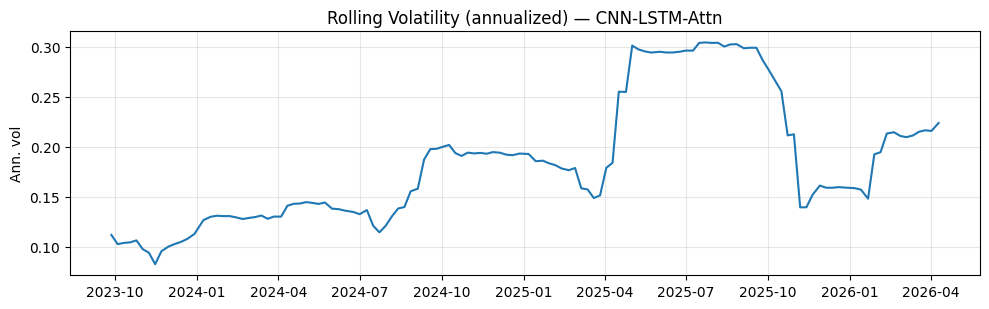

In [13]:
if "rolling_vol" in bt_indexed.columns:
    rv = bt_indexed["rolling_vol"].dropna()
else:
    rv = (r.rolling(21).std() * np.sqrt(PERIODS_PER_YEAR)).dropna()
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(rv.index, rv.values)
ax.set_title(f"Rolling Volatility (annualized) — {STRATEGY}")
ax.set_ylabel("Ann. vol"); ax.grid(alpha=.3)
_save(fig, "04_rolling_vol")


### Plot 5 — Monthly returns heatmap

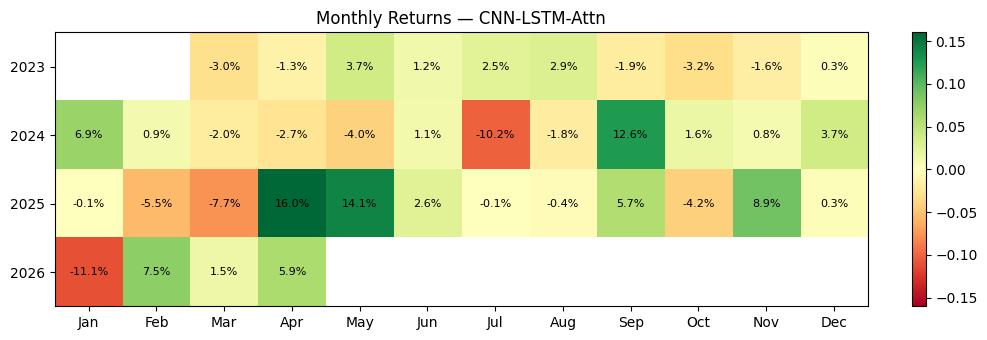

In [14]:
# Compound 5-day-bucket returns up into months
mret = (1 + r).resample("M").prod() - 1
mtbl = (mret.to_frame("ret")
              .assign(year=lambda d: d.index.year, month=lambda d: d.index.month)
              .pivot(index="year", columns="month", values="ret"))
fig, ax = plt.subplots(figsize=(10, 3.5))
arr = mtbl.values
mask = ~np.isnan(arr)
vmax = abs(arr[mask]).max() if mask.any() else 1e-3
im = ax.imshow(arr, cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_yticks(range(len(mtbl.index))); ax.set_yticklabels(mtbl.index)
for i in range(mtbl.shape[0]):
    for j in range(mtbl.shape[1]):
        v = arr[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=8, color="black")
ax.set_title(f"Monthly Returns — {STRATEGY}")
fig.colorbar(im, ax=ax, fraction=0.025)
_save(fig, "05_monthly_heatmap")


### Plot 6 — Distribution of returns (per-period)

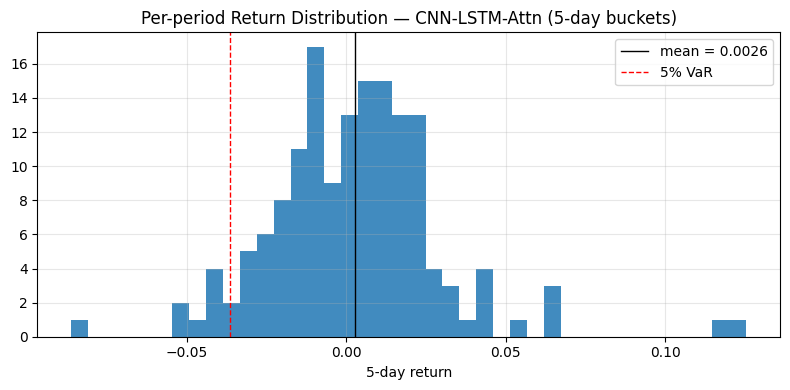

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r.values, bins=40, alpha=0.85)
ax.axvline(r.mean(),                   color="black", lw=1, label=f"mean = {r.mean():.4f}")
ax.axvline(np.quantile(r, 0.05),       color="red",   lw=1, ls="--", label="5% VaR")
ax.set_title(f"Per-period Return Distribution — {STRATEGY} ({REBALANCE_EVERY}-day buckets)")
ax.set_xlabel(f"{REBALANCE_EVERY}-day return"); ax.legend(); ax.grid(alpha=.3)
_save(fig, "06_return_distribution")


### Plot 7 — Turnover over time

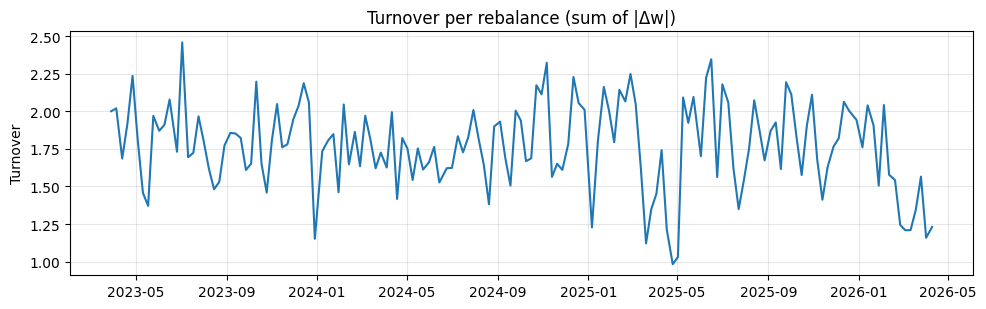

In [16]:
if "turnover" in bt_indexed.columns:
    turnover_series = bt_indexed["turnover"]
else:
    turnover_series = w.diff().abs().sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(turnover_series.index, turnover_series.values)
ax.set_title("Turnover per rebalance (sum of |Δw|)")
ax.set_ylabel("Turnover"); ax.grid(alpha=.3)
_save(fig, "07_turnover")


### Plot 8 — Gross & net exposure over time

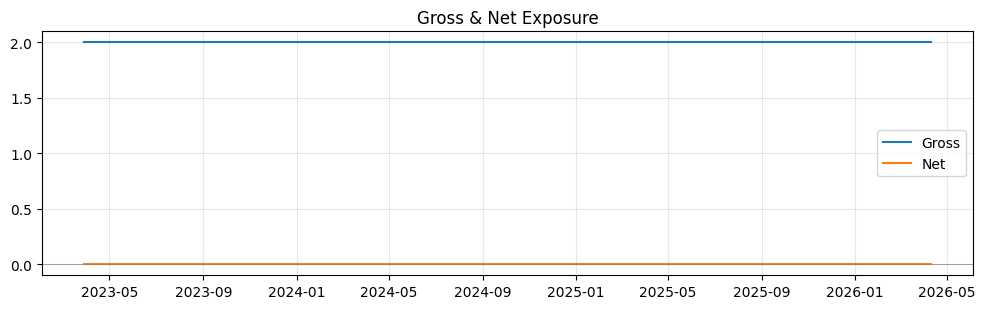

In [17]:
if "gross_exposure" in bt_indexed.columns:
    gx = bt_indexed["gross_exposure"]; nx = bt_indexed["net_exposure"]
else:
    gx = w.abs().sum(axis=1); nx = w.sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(gx.index, gx.values, label="Gross")
ax.plot(nx.index, nx.values, label="Net")
ax.axhline(0, color="grey", lw=0.5)
ax.set_title("Gross & Net Exposure"); ax.legend(); ax.grid(alpha=.3)
_save(fig, "08_exposure")


### Plot 9 — Top contributors / detractors

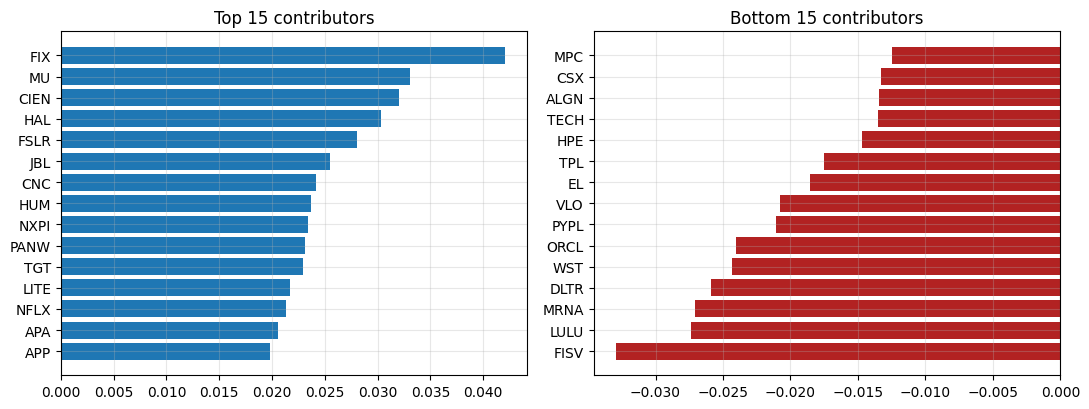

In [18]:
contrib = TICKER_PNL.sort_values(ascending=False)
top = contrib.head(15); bot = contrib.tail(15)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].barh(top.index[::-1], top.values[::-1])
axes[0].set_title("Top 15 contributors"); axes[0].grid(alpha=.3)
axes[1].barh(bot.index[::-1], bot.values[::-1], color="firebrick")
axes[1].set_title("Bottom 15 contributors"); axes[1].grid(alpha=.3)
_save(fig, "09_top_bottom_contributors")


### Plot 10 — Strategy vs. benchmark (SPY, same 5-day buckets)

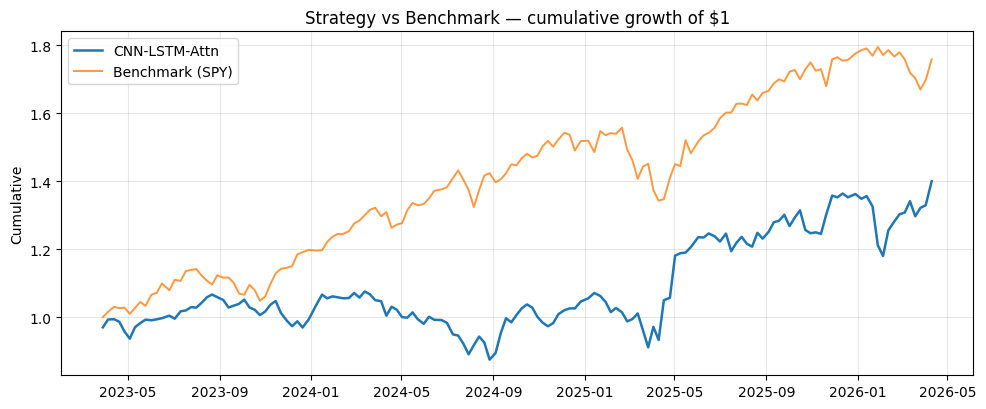

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(eq.index,   eq.values,   label=STRATEGY,         lw=1.8)
ax.plot(eq_b.index, eq_b.values, label="Benchmark (SPY)", lw=1.4, alpha=0.8)
ax.set_title("Strategy vs Benchmark — cumulative growth of $1")
ax.set_ylabel("Cumulative"); ax.grid(alpha=.3); ax.legend()
_save(fig, "10_benchmark_comparison")


In [20]:
period_tbl.to_csv(os.path.join(PLOT_DIR, "period_metrics.csv"), header=["value"])
trade_tbl.to_csv (os.path.join(PLOT_DIR, "trade_metrics.csv"),   header=["value"])
risk_tbl.to_csv  (os.path.join(PLOT_DIR, "risk_metrics.csv"),    header=["value"])
print(f"CSVs saved alongside plots in ./{PLOT_DIR}/")


CSVs saved alongside plots in ./eval_plots/


In [21]:
import shutil, os
from datetime import datetime

stamp   = datetime.now().strftime("%Y%m%d_%H%M")
zip_base = f"Group9_eval_{stamp}"
zip_path = shutil.make_archive(zip_base, "zip", "eval_plots")

print(f"Wrote {zip_path}  ({os.path.getsize(zip_path)/1024:.1f} KB)")


try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    pass

Wrote /content/Group9_eval_20260428_0318.zip  (486.7 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>